# Thesis Plotting
______________________

## Setup

### Importing Packages

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

### Directories

In [ ]:
results_dict = pd.read_pickle('MBKM_results.pkl')

## MBKM

### Optimal Number of Galaxies

In [3]:
metric_rows = []

for n_clusters, runs in results_dict.items():
    for run, data in runs.items():
        row = {
            "n_clusters": n_clusters,
            "run": run,
            "accuracy": data["accuracy"],
            "silhouette": data["silhouette"],
            "david_bouldin": data["david_bouldin"],
            "inertia": data["inertia"]
        }
        metric_rows.append(row)
full_metrics_df = pd.DataFrame(metric_rows)

metrics = ["accuracy", "inertia", "silhouette", "david_bouldin"]

# Calculating mean and std dev for each metric (for each choice of number of clusters)
plot_df = full_metrics_df.groupby("n_clusters")[metrics].agg(["mean", "std"])
# Finding the number of runs
n_runs = full_metrics_df.groupby("n_clusters").size()

# Calculate the SEM
for metric in metrics:
    plot_df[(metric, "sem")] = plot_df[(metric, "std")] / np.sqrt(n_runs)

# Reorder columns so SEM follows STD
plot_df = plot_df[
    [
        (metric, statistic)
        for metric in metrics
        for statistic in ["mean", "std", "sem"]
    ]
]
# Flatten columns
plot_df.columns = [
    f"{metric}_{statistic}"
    for metric, statistic in plot_df.columns
]

print(plot_df)

            accuracy_mean  accuracy_std  accuracy_sem  inertia_mean  \
n_clusters                                                            
10               0.703047      0.037559      0.016797  8.363298e+07   
11               0.701418      0.027766      0.012417  8.997978e+07   
12               0.691712      0.027600      0.012343  7.489221e+07   
13               0.698798      0.015200      0.006798  6.777228e+07   
14               0.713123      0.028072      0.012554  3.864377e+07   
15               0.726341      0.031511      0.014092  4.421808e+07   
16               0.728452      0.020714      0.009263  4.236471e+07   
17               0.728961      0.028073      0.012555  6.671811e+07   
18               0.716952      0.014699      0.006574  5.311017e+07   
19               0.744775      0.013739      0.006144  3.109675e+07   
20               0.734941      0.027175      0.012153  3.490371e+07   
21               0.750792      0.022909      0.010245  4.139083e+07   
22    

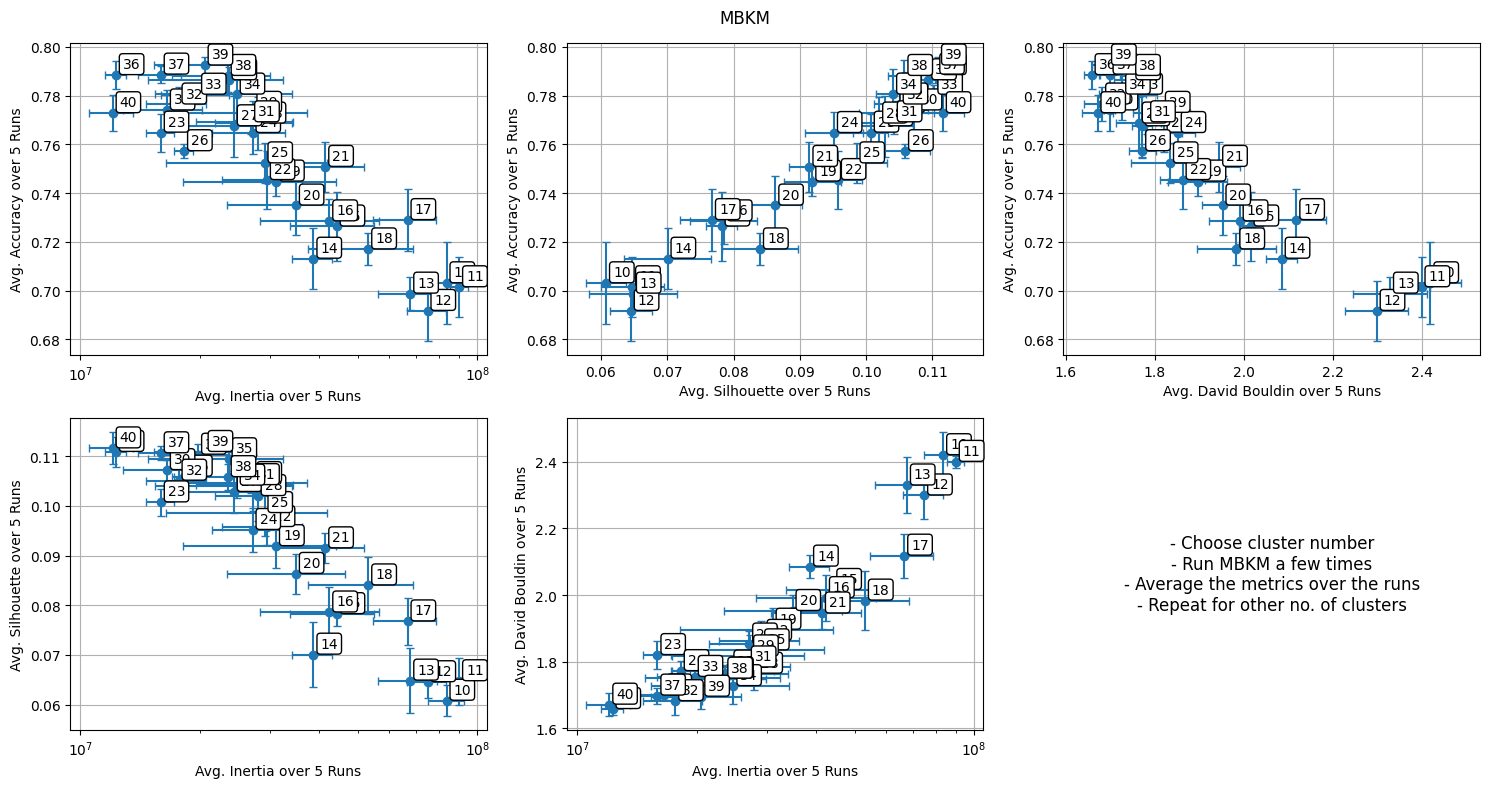

In [ ]:
def plot_metrics(ax, x_metric, y_metric, log_x=False):
    
    x_mean = f"{x_metric}_mean"
    y_mean = f"{y_metric}_mean"
    x_sem = f"{x_metric}_sem"
    y_sem = f"{y_metric}_sem"

    ax.errorbar(plot_df[x_mean], plot_df[y_mean], xerr=plot_df[x_sem], yerr=plot_df[y_sem], fmt="o", capsize=3)

    # Add cluster labels
    for cluster, row in plot_df.iterrows():
        ax.annotate(str(cluster), (row[x_mean], row[y_mean]), xytext=(5, 5), textcoords="offset points",
                    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black"))

    ax.set_xlabel(f"Avg. {x_metric.replace('_', ' ').title()} over {n_runs.iloc[0]} Runs")
    ax.set_ylabel(f"Avg. {y_metric.replace('_', ' ').title()} over {n_runs.iloc[0]} Runs")

    if log_x:
        ax.set_xscale("log")

    ax.grid(True)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

plot_metrics(ax[0, 0], "inertia", "accuracy", log_x=True)

plot_metrics(ax[0, 1], "silhouette", "accuracy")

plot_metrics(ax[0, 2], "david_bouldin", "accuracy")

plot_metrics(ax[1, 0], "inertia", "silhouette", log_x=True)

plot_metrics(ax[1, 1], "inertia", "david_bouldin", log_x=True)

ax[1,2].text(0.5, 0.5,
    f"- Choose cluster number\n- Run MBKM a few times\n- Average the metrics over the runs\n- Repeat for other no. of clusters",
    ha="center",
    va="center",
    fontsize=12
)
ax[1,2].set_axis_off()

plt.suptitle('MBKM')
plt.tight_layout()
display(fig)
plt.close(fig)